In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import timm  # for EfficientNet and modern models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Transforms with strong augmentations
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomAffine(0, scale=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], 
                         [0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], 
                         [0.229, 0.224, 0.225]),
])




In [2]:
data_root = '../data/Worksite-Safety-Monitoring-Dataset'
# Datasets
train_data = datasets.ImageFolder(data_root+"/train", transform=train_transform)
val_data   = datasets.ImageFolder(data_root+"/valid", transform=val_transform)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True, num_workers=4)
val_loader   = DataLoader(val_data, batch_size=32, shuffle=False, num_workers=4)

In [3]:
class EfficientNetClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = timm.create_model("efficientnet_b0", pretrained=True, num_classes=0)
        self.classifier = nn.Sequential(
            nn.Linear(self.backbone.num_features, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(0.5),
            nn.Linear(512, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.backbone(x)
        x = self.classifier(x)
        return x

model = EfficientNetClassifier().to(device)


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

In [4]:
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)


In [5]:
def train_model(model, train_loader, val_loader, criterion, optimizer, device, epochs=25):
    history = {
        "loss": [],
        "val_loss": [],
        "accuracy": [],
        "val_accuracy": []
    }

    for epoch in range(epochs):
        model.train()
        train_loss, train_acc, train_total = 0.0, 0.0, 0

        for inputs, labels in train_loader:
            inputs = inputs.to(device)
            labels = labels.float().unsqueeze(1).to(device)  # shape: (B, 1)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            preds = (outputs > 0.5).float()
            train_loss += loss.item() * inputs.size(0)
            train_acc += (preds == labels).sum().item()
            train_total += labels.size(0)

        train_loss /= train_total
        train_acc /= train_total

        # Validation loop
        model.eval()
        val_loss, val_acc, val_total = 0.0, 0.0, 0

        with torch.no_grad():
            for val_inputs, val_labels in val_loader:
                val_inputs = val_inputs.to(device)
                val_labels = val_labels.float().unsqueeze(1).to(device)

                val_outputs = model(val_inputs)
                loss = criterion(val_outputs, val_labels)
                preds = (val_outputs > 0.5).float()

                val_loss += loss.item() * val_inputs.size(0)
                val_acc += (preds == val_labels).sum().item()
                val_total += val_labels.size(0)

        val_loss /= val_total
        val_acc /= val_total

        # Record history
        history["loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["accuracy"].append(train_acc)
        history["val_accuracy"].append(val_acc)

        print(f"Epoch {epoch+1:2d}/{epochs} — "
              f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

    return history


In [6]:
import matplotlib.pyplot as plt

def plot_history(history):
    epochs = list(range(len(history["loss"])))

    fig, ax = plt.subplots(1, 2, figsize=(18, 6))

    # Loss plot
    ax[0].plot(epochs, history["loss"], 'ro-', label='Train Loss')
    ax[0].plot(epochs, history["val_loss"], 'b^-', label='Val Loss')
    ax[0].set_title("Loss")
    ax[0].set_xlabel("Epoch")
    ax[0].set_ylabel("Loss")
    ax[0].legend()

    # Accuracy plot
    ax[1].plot(epochs, history["accuracy"], 'ro-', label='Train Accuracy')
    ax[1].plot(epochs, history["val_accuracy"], 'b^-', label='Val Accuracy')
    ax[1].set_title("Accuracy")
    ax[1].set_xlabel("Epoch")
    ax[1].set_ylabel("Accuracy")
    ax[1].legend()

    fig.suptitle("Training Curves", fontsize=16)
    plt.tight_layout()
    plt.show()


Epoch  1/50 — Train Loss: 0.6187, Acc: 0.6605 | Val Loss: 0.4803, Acc: 0.7700
Epoch  2/50 — Train Loss: 0.3924, Acc: 0.8173 | Val Loss: 0.3846, Acc: 0.8400
Epoch  3/50 — Train Loss: 0.2640, Acc: 0.8975 | Val Loss: 0.3442, Acc: 0.8800
Epoch  4/50 — Train Loss: 0.1901, Acc: 0.9358 | Val Loss: 0.3512, Acc: 0.8800
Epoch  5/50 — Train Loss: 0.1312, Acc: 0.9543 | Val Loss: 0.3390, Acc: 0.8650
Epoch  6/50 — Train Loss: 0.1195, Acc: 0.9617 | Val Loss: 0.3427, Acc: 0.8650
Epoch  7/50 — Train Loss: 0.0845, Acc: 0.9728 | Val Loss: 0.3375, Acc: 0.8750
Epoch  8/50 — Train Loss: 0.0847, Acc: 0.9753 | Val Loss: 0.3870, Acc: 0.8700
Epoch  9/50 — Train Loss: 0.0628, Acc: 0.9790 | Val Loss: 0.4207, Acc: 0.8700
Epoch 10/50 — Train Loss: 0.0626, Acc: 0.9827 | Val Loss: 0.3908, Acc: 0.8850
Epoch 11/50 — Train Loss: 0.0525, Acc: 0.9815 | Val Loss: 0.3744, Acc: 0.8850
Epoch 12/50 — Train Loss: 0.0392, Acc: 0.9883 | Val Loss: 0.4144, Acc: 0.8800
Epoch 13/50 — Train Loss: 0.0336, Acc: 0.9858 | Val Loss: 0.4107

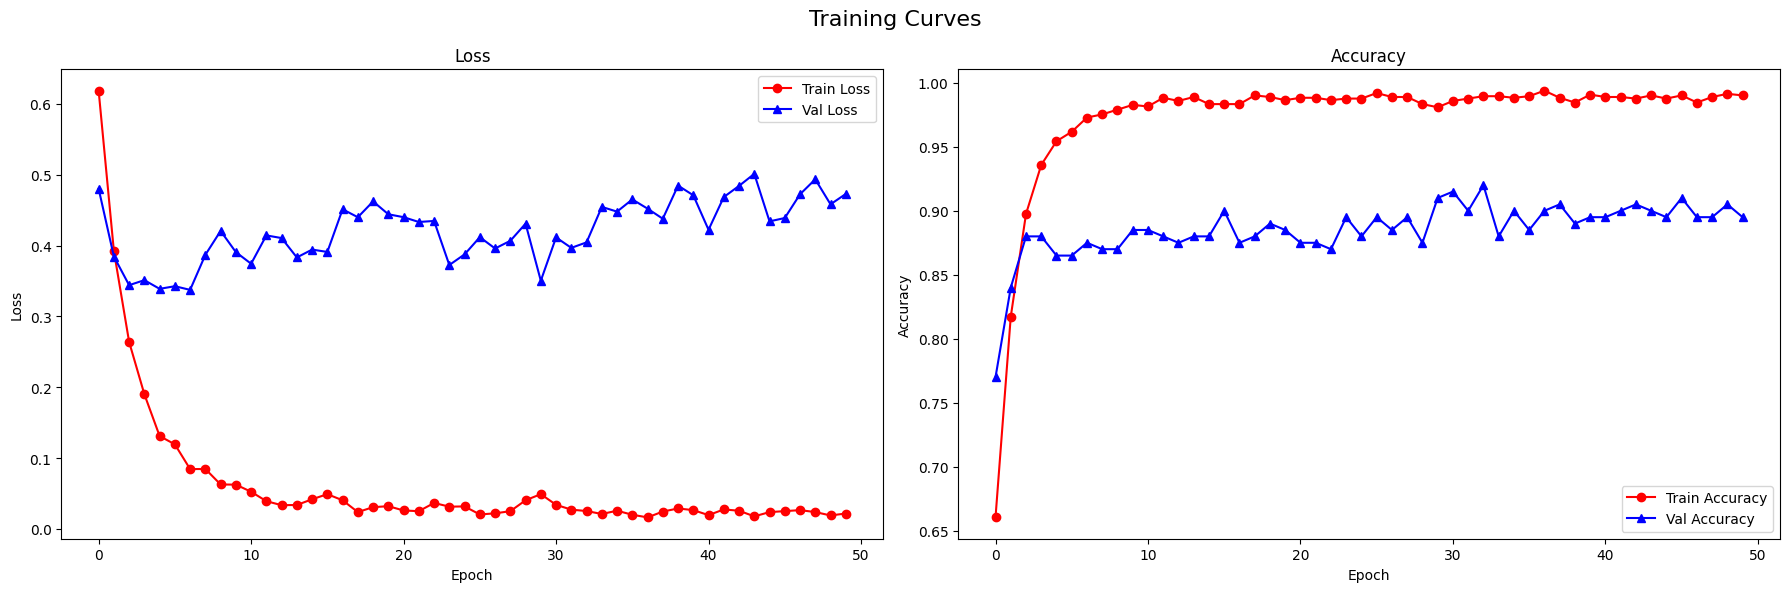

In [7]:
history = train_model(model, train_loader, val_loader, criterion, optimizer, device, epochs=50)
plot_history(history)


In [9]:
torch.save(model.state_dict(), "../models/best_model.pth")
